In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vivekkumar30112006/segresnet-checkpoint/training_checkpoint.pth
/kaggle/input/datasets/vivekkumar30112006/segresnet-checkpoint/best_metric_model.pth
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/._Task08_HepaticVessel
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._labelsTr
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._imagesTr
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._imagesTs
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/._dataset.json
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/dataset.json
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imagesTs/._hepaticvessel_204.nii.gz
/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel/imagesTs/._hepaticvessel_060.nii.gz
/kaggle/input/datasets/isobel

In [2]:
import os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import torch

print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    cap  = torch.cuda.get_device_capability(0)
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU     : {name}")
    print(f"Compute : sm_{cap[0]}{cap[1]}")
    print(f"VRAM    : {vram:.1f} GB")

PyTorch : 2.10.0+cu128
GPU     : Tesla T4
Compute : sm_75
VRAM    : 15.6 GB
GPU OK.


In [3]:
!pip install -q monai nibabel tqdm
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 67.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incomp

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import subprocess, shutil

import torch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from monai.config import print_config
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet
from monai.data import DataLoader, Dataset, decollate_batch
from monai.utils import first
from monai.transforms import (
    AsDiscrete, Compose, CropForegroundd, LoadImaged,
    Orientationd, RandFlipd, RandCropByPosNegLabeld,
    RandShiftIntensityd, ScaleIntensityRanged, Spacingd,
    RandRotate90d, EnsureTyped, RandGaussianNoised,
    RandScaleIntensityd, RandAdjustContrastd, RandZoomd,
)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-06-12 01:19:01.577011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781227141.745058      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781227141.794984      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781227142.217138      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781227142.217184      58 computation_placer.cc:1

MONAI version: 1.5.2
Numpy version: 2.4.6
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.4
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#insta

In [5]:
# Dataset
DATA_ROOT = '/kaggle/input/datasets/isobelmackie/msd-task08-hepatic-vessel/Task08_HepaticVessel'

# Output
WORK_DIR = '/kaggle/working/'
os.makedirs(WORK_DIR, exist_ok=True)

CHECKPOINT_PATH    = os.path.join(WORK_DIR, 'training_checkpoint.pth')
BEST_MODEL_PATH    = os.path.join(WORK_DIR, 'best_metric_model.pth')

# Kaggle dataset for auto-push
KAGGLE_USERNAME    = 'vivekkumar30112006'
KAGGLE_DATASET_ID  = f'{KAGGLE_USERNAME}/segresnet-checkpoint'

# Hyperparameters
NUM_CLASSES    = 3       # background(0), vessel(1), tumor(2)
num_samples    = 4       
max_iterations = 10000  
eval_num       = 500     # validate + save + auto-push every 500 steps
warmup_steps   = 0     

# Load dataset.json
with open(os.path.join(DATA_ROOT, 'dataset.json')) as f:
    dataset_info = json.load(f)

print('Dataset :', dataset_info.get('name'))
print('Labels  :', dataset_info.get('labels', {}))

def resolve_path(p):
    rel  = p.lstrip('./')
    full = os.path.join(DATA_ROOT, rel)
    if os.path.exists(full): return full
    if full.endswith('.gz') and os.path.exists(full[:-3]): return full[:-3]
    if not full.endswith('.gz') and os.path.exists(full+'.gz'): return full+'.gz'
    return full

all_files = []
for entry in dataset_info.get('training', []):
    img = resolve_path(entry['image'])
    lbl = resolve_path(entry['label'])
    if os.path.exists(img) and os.path.exists(lbl):
        all_files.append({'image': img, 'label': lbl})

VAL_SIZE    = 20
train_files = all_files[:-VAL_SIZE]
val_files   = all_files[-VAL_SIZE:]

print(f"\nTotal pairs   : {len(all_files)}")
print(f"Training      : {len(train_files)}")
print(f"Validation    : {len(val_files)}")
print(f"\nMax steps     : {max_iterations}")
print(f"Eval every    : {eval_num} steps")
print(f"Patches/step  : {num_samples}  (4 fits in T4 with SegResNet)")

Dataset : HepaticVessel
Labels  : {'0': 'background', '1': 'Vessel', '2': 'Tumour'}

Total pairs   : 303
Training      : 283
Validation    : 20

Max steps     : 10000
Eval every    : 500 steps
Patches/step  : 4  (4 fits in T4 with SegResNet)


In [6]:
# Visualization only
orig_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
    EnsureTyped(keys=['image', 'label'], track_meta=False),
])

# Training pipeline
train_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
    ScaleIntensityRanged(
        keys=['image'], a_min=-175, a_max=250,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    CropForegroundd(keys=['image', 'label'], source_key='image'),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(
        keys=['image', 'label'],
        pixdim=(1.0, 1.0, 1.0),
        mode=('bilinear', 'nearest'),
    ),
    EnsureTyped(keys=['image', 'label'], track_meta=False),
    RandCropByPosNegLabeld(
        keys=['image', 'label'], label_key='label',
        spatial_size=(96, 96, 96),
        pos=2, neg=1,
        num_samples=num_samples,
        image_key='image', image_threshold=0,
    ),
    # Fast spatial augmentations (kept)
    RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=0.5),
    RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=0.5),
    RandFlipd(keys=['image', 'label'], spatial_axis=[2], prob=0.5),
    RandRotate90d(keys=['image', 'label'], prob=0.25, max_k=3),
    # Fast intensity augmentations (kept)
    RandShiftIntensityd(keys=['image'], offsets=0.10, prob=0.5),
    RandScaleIntensityd(keys=['image'], factors=0.15, prob=0.5),
])

# Validation: preprocessing only
val_transforms = Compose([
    LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
    ScaleIntensityRanged(
        keys=['image'], a_min=-175, a_max=250,
        b_min=0.0, b_max=1.0, clip=True,
    ),
    CropForegroundd(keys=['image', 'label'], source_key='image'),
    Orientationd(keys=['image', 'label'], axcodes='RAS'),
    Spacingd(
        keys=['image', 'label'],
        pixdim=(1.0, 1.0, 1.0),
        mode=('bilinear', 'nearest'),
    ),
    EnsureTyped(keys=['image', 'label'], track_meta=True),
])

print("Transforms defined.")

Transforms defined.
  Removed: RandZoomd, RandAdjustContrastd, RandGaussianNoised (slow)
  Kept   : Flip x3, Rotate90, ShiftIntensity, ScaleIntensity (fast)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [7]:
from monai.data import CacheDataset

orig_ds     = Dataset(data=train_files, transform=orig_transforms)
orig_loader = DataLoader(orig_ds, batch_size=1, num_workers=0)

train_ds     = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(
    train_ds, batch_size=1, shuffle=True,
    num_workers=2,
    persistent_workers=True,  # workers stay alive between steps — no restart overhead
    pin_memory=True
)

print("Caching 20 validation volumes into RAM...")
val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,    
    num_workers=2,
)
val_loader = DataLoader(
    val_ds, batch_size=1,
    num_workers=0,     # 0 for val since data is already in RAM
    pin_memory=True
)

print(f"Training   : {len(train_ds)} volumes × {num_samples} patches")
print(f"Validation : {len(val_ds)} volumes (cached in RAM)")
print(f"Expected speed : ~4s/step")

Caching 20 validation volumes into RAM...


Loading dataset: 100%|██████████| 20/20 [01:06<00:00,  3.33s/it]

Training   : 283 volumes × 4 patches
Validation : 20 volumes (cached in RAM)
Expected speed : ~4s/step


Original shape    : torch.Size([1, 1, 512, 512, 49])
Preprocessed shape: torch.Size([4, 1, 96, 96, 96])


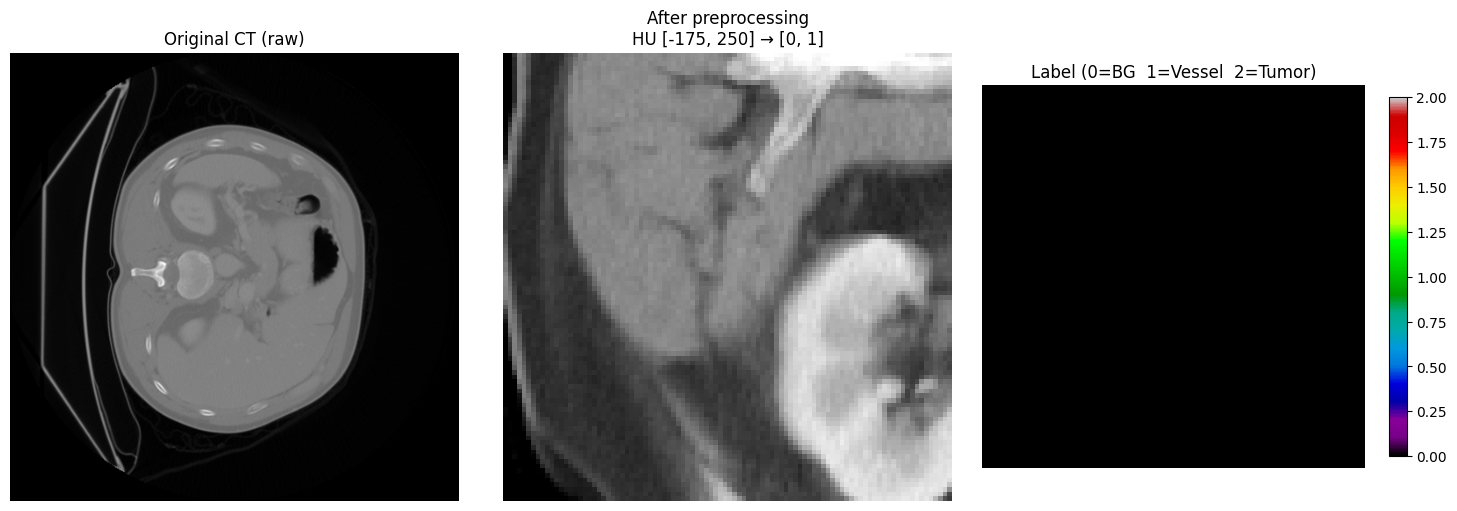

Saved.


In [8]:
orig_patient = first(orig_loader)
test_patient = first(train_loader)

print(f"Original shape    : {orig_patient['image'].shape}")
print(f"Preprocessed shape: {test_patient['image'].shape}")

depth  = orig_patient['image'].shape[-1]
slices = depth // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].set_title("Original CT (raw)")
axes[0].imshow(orig_patient['image'][0, 0, :, :, slices], cmap='gray')
axes[0].axis('off')

axes[1].set_title("After preprocessing\nHU [-175, 250] → [0, 1]")
axes[1].imshow(test_patient['image'][0, 0, :, :, slices], cmap='gray')
axes[1].axis('off')

axes[2].set_title("Label (0=BG  1=Vessel  2=Tumor)")
im = axes[2].imshow(
    test_patient['label'][0, 0, :, :, slices],
    cmap='nipy_spectral', vmin=0, vmax=2
)
plt.colorbar(im, ax=axes[2], shrink=0.8)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'sample_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [9]:
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SegResNet(
    blocks_down=[1, 2, 2, 4],   # encoder: progressively deeper
    blocks_up=[1, 1, 1],         # decoder: symmetric upsampling
    init_filters=32,             # network width (32=fast, 64=accurate)
    in_channels=1,               # CT grayscale
    out_channels=3,              # background, vessel, tumor
    dropout_prob=0.2,            # regularization
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel          : SegResNet")
print(f"Total params   : {total:,}  (vs 62M for SwinUNETR)")
print(f"Trainable      : {trainable:,}")

Device: cuda

Model          : SegResNet
Total params   : 18,796,035  (vs 62M for SwinUNETR)
Trainable      : 18,796,035
No pretrained weights needed — trains well from scratch
Expected speed : ~4s/step (vs ~13s/step for SwinUNETR)


In [10]:
torch.backends.cudnn.benchmark = True

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# SECOND CYCLE: lower LR for fine-tuning from step 8000
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.5e-5,           
    weight_decay=1e-5,
)

scaler = torch.amp.GradScaler('cuda')

post_label      = AsDiscrete(to_onehot=NUM_CLASSES)
post_pred       = AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)
dice_metric     = DiceMetric(include_background=True, reduction='mean',
                             get_not_nans=False)
dice_metric_cls = DiceMetric(include_background=True, reduction='mean_batch',
                             get_not_nans=False)

scheduler = CosineAnnealingLR(
    optimizer, T_max=2000, eta_min=1e-8
)

print("Second cycle configured.")
print(f"  Loss      : DiceCELoss")
print(f"  Optimizer : AdamW  lr=3e-5  wd=1e-5")
print(f"  Grad clip : max_norm=1.0")

Second cycle configured.
  Loss      : DiceCELoss
  Optimizer : AdamW  lr=3e-5  wd=1e-5
  Schedule  : CosineAnnealing  3e-5 → 1e-7  over 3000 steps
  Grad clip : max_norm=1.0


In [11]:
def push_to_kaggle(global_step, dice_val_best):
    """Auto-push checkpoint to Kaggle dataset after every save."""
    try:
        push_dir = '/kaggle/working/push_tmp'
        os.makedirs(push_dir, exist_ok=True)
        shutil.copy(CHECKPOINT_PATH, os.path.join(push_dir, 'training_checkpoint.pth'))
        if os.path.exists(BEST_MODEL_PATH):
            shutil.copy(BEST_MODEL_PATH, os.path.join(push_dir, 'best_metric_model.pth'))
        metadata = {
            "title": "segresnet-checkpoint",
            "id"   : KAGGLE_DATASET_ID,
            "licenses": [{"name": "CC0-1.0"}]
        }
        with open(os.path.join(push_dir, 'dataset-metadata.json'), 'w') as f:
            json.dump(metadata, f)
        result = subprocess.run(
            ['kaggle', 'datasets', 'version',
             '-p', push_dir,
             '-m', f'step_{global_step}_dice_{dice_val_best:.4f}',
             '--dir-mode', 'zip'],
            capture_output=True, text=True, timeout=600
        )
        if result.returncode == 0:
            print(f"  Auto-pushed to Kaggle at step {global_step}")
        else:
            print(f"  Push failed (checkpoint safe locally): {result.stderr[:100]}")
    except Exception as e:
        print(f"  Auto-push skipped: {e}")


def save_checkpoint(global_step, dice_val_best, global_step_best,
                    epoch_loss_values, metric_values, class_dice_history):
    """Save locally + auto-push to Kaggle dataset."""
    torch.save({
        'global_step'          : global_step,
        'model_state_dict'     : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'scaler_state_dict'    : scaler.state_dict(),
        'scheduler_state_dict' : scheduler.state_dict(),
        'dice_val_best'        : dice_val_best,
        'global_step_best'     : global_step_best,
        'epoch_loss_values'    : epoch_loss_values,
        'metric_values'        : metric_values,
        'class_dice_history'   : class_dice_history,
    }, CHECKPOINT_PATH)
    size = os.path.getsize(CHECKPOINT_PATH) / 1e6
    print(f"  Saved locally → {CHECKPOINT_PATH}  ({size:.0f} MB)")
    push_to_kaggle(global_step, dice_val_best)


def load_checkpoint():
    """Search multiple locations for checkpoint."""
    search_paths = [
        f'/kaggle/input/datasets/{KAGGLE_USERNAME}/segresnet-checkpoint/training_checkpoint.pth',
        f'/kaggle/input/segresnet-checkpoint/training_checkpoint.pth',
        CHECKPOINT_PATH,
    ]

    found = None
    for path in search_paths:
        if os.path.exists(path) and os.path.getsize(path) > 10000:
            found = path
            break

    if found:
        print(f"Checkpoint found : {found}")
        print(f"File size        : {os.path.getsize(found)/1e6:.0f} MB")
        ckpt = torch.load(found, map_location=device)

        # Always load model weights
        model.load_state_dict(ckpt['model_state_dict'])

        # Always load scaler
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        global_step        = ckpt['global_step']
        dice_val_best      = ckpt['dice_val_best']
        global_step_best   = ckpt['global_step_best']
        epoch_loss_values  = ckpt['epoch_loss_values']
        metric_values      = ckpt['metric_values']
        class_dice_history = ckpt.get('class_dice_history', [])

        print(f"Resuming from step {global_step} | Best Dice: {dice_val_best:.4f}")
        print(f"Fresh LR: {optimizer.param_groups[0]['lr']:.2e}  (second cycle)")
        return global_step, dice_val_best, global_step_best, \
               epoch_loss_values, metric_values, class_dice_history
    else:
        print("No checkpoint found — starting fresh from step 0.")
        return 0, 0.0, 0, [], [], []


print("Checkpoint functions ready.")
print(f"Auto-push target : {KAGGLE_DATASET_ID}")

Checkpoint functions ready.
Auto-push target : vivekkumar30112006/segresnet-checkpoint


In [12]:
def validation(epoch_iterator_val, global_step):
    """Run inference on all 20 validation volumes."""
    model.eval()
    dice_metric.reset()
    dice_metric_cls.reset()

    with torch.no_grad():
        for batch in epoch_iterator_val:
            val_inputs = batch['image'].to(device)
            val_labels = batch['label'].to(device)

            with torch.amp.autocast('cuda'):
                val_outputs = sliding_window_inference(
                    val_inputs,
                    roi_size=(96, 96, 96),
                    sw_batch_size=4,   # SegResNet is small — 4 windows fits
                    predictor=model,
                    overlap=0.5,      
                )

            val_labels_conv  = [post_label(x) for x in decollate_batch(val_labels)]
            val_outputs_conv = [post_pred(x)  for x in decollate_batch(val_outputs)]

            dice_metric(y_pred=val_outputs_conv, y=val_labels_conv)
            dice_metric_cls(y_pred=val_outputs_conv, y=val_labels_conv)
            epoch_iterator_val.set_description(f"Validate (step {global_step})")

    mean_dice  = dice_metric.aggregate().item()
    class_dice = dice_metric_cls.aggregate()
    dice_metric.reset()
    dice_metric_cls.reset()

    print(f"  Mean Dice  : {mean_dice:.4f}")
    print(f"  BG         : {class_dice[0]:.4f}")
    print(f"  Vessel     : {class_dice[1]:.4f}  ← most important")
    print(f"  Tumor      : {class_dice[2]:.4f}")
    return mean_dice, class_dice.tolist()


print("Validation function ready.")

Validation function ready.


In [13]:
def train(global_step, train_loader, dice_val_best, global_step_best,
          epoch_loss_values, metric_values, class_dice_history):
    """One epoch of training."""
    model.train()
    epoch_loss = 0
    step = 0

    epoch_iterator = tqdm(
        train_loader,
        desc=f"Training ({global_step}/{max_iterations})",
        dynamic_ncols=True,
    )

    for step, batch in enumerate(epoch_iterator):
        step += 1
        x = batch['image'].to(device)
        y = batch['label'].to(device)

        with torch.amp.autocast('cuda'):
            logit_map = model(x)
            loss = loss_function(logit_map, y)

        scaler.scale(loss).backward()
        epoch_loss += loss.item()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step()
        torch.cuda.empty_cache()

        current_lr = optimizer.param_groups[0]['lr']
        epoch_iterator.set_description(
            f"Training ({global_step}/{max_iterations}) "
            f"loss={loss.item():.5f} lr={current_lr:.2e}"
        )

        if (global_step % eval_num == 0 and global_step != 0) or global_step == max_iterations:
            print(f"\n--- Evaluation at step {global_step} ---")
            val_iter = tqdm(val_loader, desc="Validating...", dynamic_ncols=True)
            dice_val, class_dice = validation(val_iter, global_step)

            epoch_loss_values.append(epoch_loss / step)
            metric_values.append(dice_val)
            class_dice_history.append(class_dice)

            if dice_val > dice_val_best:
                dice_val_best    = dice_val
                global_step_best = global_step
                torch.save(model.state_dict(), BEST_MODEL_PATH)
                print(f"  NEW BEST  Dice: {dice_val_best:.4f}  at step {global_step}")
            else:
                print(f"  No improvement. Best: {dice_val_best:.4f}  Current: {dice_val:.4f}")

            save_checkpoint(global_step, dice_val_best, global_step_best,
                           epoch_loss_values, metric_values, class_dice_history)

        global_step += 1
        if global_step > max_iterations:
            break

    return global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history


print("Training function ready.")

Training function ready.


In [14]:
global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history = load_checkpoint()

print(f"\nModel          : SegResNet")
print(f"Starting step  : {global_step}")
print(f"Target steps   : {max_iterations}")
print(f"Remaining      : {max_iterations - global_step}")
print(f"Best Dice so far: {dice_val_best:.4f}")
print()

while global_step < max_iterations:
    global_step, dice_val_best, global_step_best, epoch_loss_values, metric_values, class_dice_history = train(
        global_step, train_loader, dice_val_best, global_step_best,
        epoch_loss_values, metric_values, class_dice_history
    )

print(f"\n{'='*55}")
print(f"Training complete!")
print(f"Best Dice  : {dice_val_best:.4f}")
print(f"At step    : {global_step_best}")
print(f"{'='*55}")

Checkpoint found : /kaggle/input/datasets/vivekkumar30112006/segresnet-checkpoint/training_checkpoint.pth
File size        : 226 MB
Resuming from step 8000 | Best Dice: 0.6828
Fresh LR: 1.50e-05  (second cycle)

Model          : SegResNet
Starting step  : 8000
Target steps   : 10000
Remaining      : 2000
Best Dice so far: 0.6828



Training (8000/10000) loss=0.61997 lr=1.50e-05:   0%|          | 0/283 [00:13<?, ?it/s]


--- Evaluation at step 8000 ---



Validating...:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/

  Mean Dice  : 0.6844
  BG         : 0.9991
  Vessel     : 0.5870  ← most important
  Tumor      : 0.4670
  NEW BEST  Dice: 0.6844  at step 8000
  Saved locally → /kaggle/working/training_checkpoint.pth  (226 MB)


...


--- Evaluation at step 10000 ---



Validating...:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/

  Mean Dice  : 0.6906
  BG         : 0.9992
  Vessel     : 0.5926  ← most important
  Tumor      : 0.4799
  NEW BEST  Dice: 0.6906  at step 10000
  Saved locally → /kaggle/working/training_checkpoint.pth  (226 MB)


Training (10000/10000) loss=0.72268 lr=1.00e-08:   7%|▋         | 19/283 [06:57<1:36:35, 21.95s/it]

  Auto-pushed to Kaggle at step 10000

Training complete!
Best Dice  : 0.6906
At step    : 10000


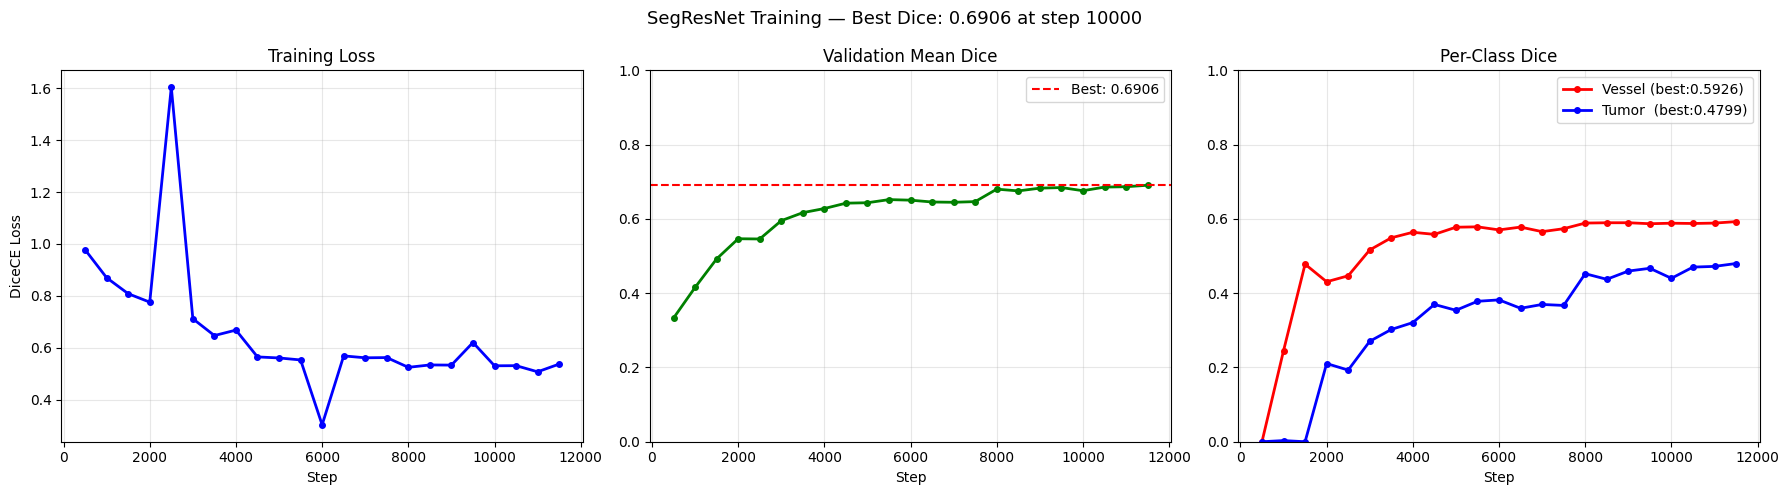

Saved.


In [15]:
if len(epoch_loss_values) == 0:
    print("No data yet.")
else:
    x = [eval_num * (i + 1) for i in range(len(epoch_loss_values))]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"SegResNet Training — Best Dice: {dice_val_best:.4f} at step {global_step_best}",
                 fontsize=13)

    axes[0].set_title("Training Loss")
    axes[0].plot(x, epoch_loss_values, 'b-o', linewidth=2, markersize=4)
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("DiceCE Loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Validation Mean Dice")
    axes[1].plot(x, metric_values, 'g-o', linewidth=2, markersize=4)
    if dice_val_best > 0:
        axes[1].axhline(y=dice_val_best, color='red', linestyle='--',
                        label=f"Best: {dice_val_best:.4f}")
        axes[1].legend()
    axes[1].set_ylim(0, 1); axes[1].set_xlabel("Step")
    axes[1].grid(True, alpha=0.3)

    if len(class_dice_history) > 0:
        vessel = [c[1] for c in class_dice_history]
        tumor  = [c[2] for c in class_dice_history]
        axes[2].set_title("Per-Class Dice")
        axes[2].plot(x[:len(vessel)], vessel, 'r-o', linewidth=2, markersize=4,
                     label=f"Vessel (best:{max(vessel):.4f})")
        axes[2].plot(x[:len(tumor)],  tumor,  'b-o', linewidth=2, markersize=4,
                     label=f"Tumor  (best:{max(tumor):.4f})")
        axes[2].set_ylim(0, 1); axes[2].set_xlabel("Step")
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved.")

Loaded best model. Dice: 0.6906


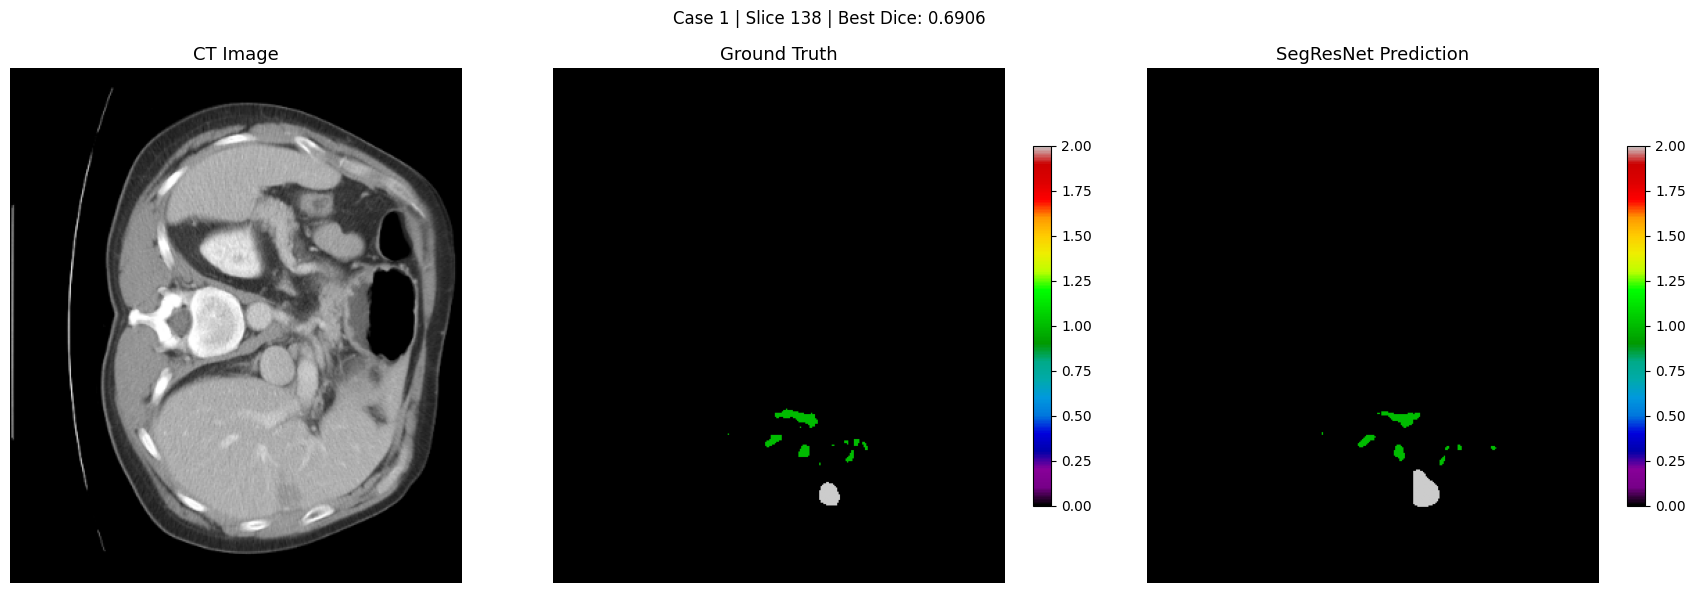

In [21]:
if not os.path.exists(BEST_MODEL_PATH):
    print("Best model not saved yet — run Cell 13 first.")
else:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()
    print(f"Loaded best model. Dice: {dice_val_best:.4f}")

    case_num = 1

    with torch.no_grad():
        sample     = val_ds[case_num]
        val_inputs = torch.unsqueeze(sample['image'], 0).to(device)
        val_labels = torch.unsqueeze(sample['label'], 0).to(device)

        with torch.amp.autocast('cuda'):
            val_outputs = sliding_window_inference(
                val_inputs, (96,96,96), 4, model, overlap=0.5
            )

    label_np  = val_labels.cpu().numpy()[0, 0]
    annotated = np.where(label_np.sum(axis=(0,1)) > 0)[0]
    vis_slice = int(annotated[len(annotated)//2]) if len(annotated) > 0 else label_np.shape[-1]//2

    pred = torch.argmax(val_outputs, dim=1).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].set_title("CT Image", fontsize=13)
    axes[0].imshow(val_inputs.cpu().numpy()[0,0,:,:,vis_slice], cmap='gray')
    axes[0].axis('off')

    axes[1].set_title("Ground Truth", fontsize=13)
    im = axes[1].imshow(val_labels.cpu().numpy()[0,0,:,:,vis_slice],
                        cmap='nipy_spectral', vmin=0, vmax=2)
    plt.colorbar(im, ax=axes[1], shrink=0.7); axes[1].axis('off')

    axes[2].set_title("SegResNet Prediction", fontsize=13)
    im = axes[2].imshow(pred[0,:,:,vis_slice], cmap='nipy_spectral', vmin=0, vmax=2)
    plt.colorbar(im, ax=axes[2], shrink=0.7); axes[2].axis('off')

    plt.suptitle(f"Case {case_num} | Slice {vis_slice} | Best Dice: {dice_val_best:.4f}")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'prediction_case_{case_num}.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [22]:
print("=" * 58)
print("   EXPERIMENT SUMMARY -(SegResNet)")
print("=" * 58)
print(f"  Dataset          : MSD Task08 Hepatic Vessel")
print(f"  Train / Val      : {len(train_files)} / {len(val_files)}")
print(f"  Model            : SegResNet (init_filters=32)")
print(f"  Parameters       : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Loss             : DiceCELoss")
print(f"  Optimizer        : AdamW  lr=2e-4  wd=1e-5")
print(f"  LR Schedule      : LinearWarmup({warmup_steps}) + CosineAnnealing")
print(f"  Grad clipping    : max_norm=1.0")
print(f"  Patch size       : 96 × 96 × 96")
print(f"  Patches/volume   : {num_samples}  (pos:neg = 2:1)")
print(f"  HU window        : [-175, 250]")
print(f"  Val overlap      : 0.5")
print(f"  Max iterations   : {max_iterations}")
print(f"  Eval every       : {eval_num} steps")
print(f"  Auto-push        : {KAGGLE_DATASET_ID}")
print("-" * 58)
print(f"  Steps completed  : {global_step}")
print(f"  Best Mean Dice   : {dice_val_best:.4f}")
print(f"  Best at step     : {global_step_best}")
if len(class_dice_history) > 0 and len(metric_values) > 0:
    best_idx = metric_values.index(max(metric_values))
    bd       = class_dice_history[best_idx]
    print(f"  Best Vessel Dice : {bd[1]:.4f}")
    print(f"  Best Tumor Dice  : {bd[2]:.4f}")
print(f"  Checkpoint       : {CHECKPOINT_PATH}")
print(f"  Best model       : {BEST_MODEL_PATH}")
print("=" * 58)

   EXPERIMENT SUMMARY —(SegResNet)
  Dataset          : MSD Task08 Hepatic Vessel
  Train / Val      : 283 / 20
  Model            : SegResNet (init_filters=32)
  Parameters       : 18,796,035
  Loss             : DiceCELoss
  Optimizer        : AdamW  lr=2e-4  wd=1e-5
  LR Schedule      : LinearWarmup(0) + CosineAnnealing
  Grad clipping    : max_norm=1.0
  Patch size       : 96 × 96 × 96
  Patches/volume   : 4  (pos:neg = 2:1)
  HU window        : [-175, 250]
  Val overlap      : 0.5
  Max iterations   : 10000
  Eval every       : 500 steps
  Auto-push        : vivekkumar30112006/segresnet-checkpoint
----------------------------------------------------------
  Steps completed  : 10001
  Best Mean Dice   : 0.6906
  Best at step     : 10000
  Best Vessel Dice : 0.5926
  Best Tumor Dice  : 0.4799
  Checkpoint       : /kaggle/working/training_checkpoint.pth
  Best model       : /kaggle/working/best_metric_model.pth
